In [2]:
import pandas as pd
import numpy as np
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Constants
NUM_SAMPLES = 10000
RACES = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
RACE_WEIGHTS = [0.50, 0.25, 0.10, 0.10, 0.05]  # Prevalence-based

# Helper to simulate diagnosis based on feature correlations
def simulate_diagnosis(age, psa, dre, fh, bone_pain, weight_loss):
    score = 0
    score += (age - 50) * 0.05
    score += (psa - 4) * 0.4
    score += dre * 2
    score += fh * 1.5
    score += bone_pain * 1.5
    score += weight_loss * 1.0
    probability = 1 / (1 + np.exp(-score))  # Sigmoid function
    return 1 if probability > 0.6 else 0

# Generate data
data = []
for i in range(1, NUM_SAMPLES + 1):
    patient_id = f'P{i:05d}'
    age = np.random.randint(40, 90)
    race = np.random.choice(RACES, p=RACE_WEIGHTS)
    bmi = round(np.random.normal(27, 4), 1)  # Normal BMI distribution
    family_history = np.random.choice([0, 1], p=[0.8, 0.2])
    psa_level = round(np.random.normal(5 + (age - 50) * 0.1, 2.0), 2)
    prostate_volume = round(np.random.normal(35 + (age - 50) * 0.5, 10), 2)
    dre_result = np.random.choice([0, 1], p=[0.85, 0.15])
    urinary_frequency = np.random.randint(0, 11)
    nocturia = np.random.poisson(1.5)
    nocturia = min(nocturia, 5)
    weak_urine_stream = np.random.choice([0, 1], p=[0.7, 0.3])
    hematuria = np.random.choice([0, 1], p=[0.9, 0.1])
    erectile_dysfunction = np.random.choice([0, 1], p=[0.7, 0.3])
    pain_in_pelvis = np.random.choice([0, 1], p=[0.9, 0.1])
    bone_pain = np.random.choice([0, 1], p=[0.95, 0.05])
    weight_loss = np.random.choice([0, 1], p=[0.93, 0.07])

    diagnosis = simulate_diagnosis(age, psa_level, dre_result, family_history, bone_pain, weight_loss)

    data.append([
        patient_id, age, race, bmi, family_history, psa_level, prostate_volume,
        dre_result, urinary_frequency, nocturia, weak_urine_stream, hematuria,
        erectile_dysfunction, pain_in_pelvis, bone_pain, weight_loss, diagnosis
    ])

# Define DataFrame
columns = [
    'patient_id', 'age', 'race', 'bmi', 'family_history', 'psa_level',
    'prostate_volume', 'dre_result', 'urinary_frequency', 'nocturia',
    'weak_urine_stream', 'hematuria', 'erectile_dysfunction', 'pain_in_pelvis',
    'bone_pain', 'weight_loss', 'diagnosis'
]

df = pd.DataFrame(data, columns=columns)

# Save to CSV
df.to_csv('prostate_cancer_dataset.csv', index=False)

print("✅ Dataset generated and saved as 'prostate_cancer_dataset.csv'")


✅ Dataset generated and saved as 'prostate_cancer_dataset.csv'


In [3]:
df.head(50)

,patient_id,age,race,bmi,family_history,psa_level,prostate_volume,dre_result,urinary_frequency,nocturia,weak_urine_stream,hematuria,erectile_dysfunction,pain_in_pelvis,bone_pain,weight_loss,diagnosis
0,P00001,78,Asian,29.2,0,6.57,39.83,0,4,2,1,0,0,0,0,0,1
1,P00002,61,White,26.5,0,1.22,46.53,0,2,2,1,0,0,0,0,0,0
2,P00003,48,White,24.0,0,3.24,45.30,0,0,1,0,0,0,0,1,0,1
3,P00004,73,White,28.5,1,5.49,58.39,0,8,4,1,0,0,0,0,0,1
4,P00005,48,Asian,29.3,0,6.58,25.61,1,7,1,0,0,0,0,0,0,1
5,P00006,74,White,25.8,0,8.12,62.38,0,6,0,1,0,0,0,0,0,1
6,P00007,71,Black,28.2,0,5.04,61.73,1,9,4,1,0,1,0,0,0,1
7,P00008,66,White,30.3,1,1.29,46.46,0,2,1,0,0,0,0,0,0,1
8,P00009,51,White,19.3,0,5.05,36.52,0,5,0,0,0,0,0,0,0,1
9,P00010,43,White,25.3,0,5.76,25.31,0,1,2,1,0,0,0,0,0,0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix

# Make output folder
os.makedirs("model_outputs", exist_ok=True)

# Save classification report as image
def save_classification_report_image(y_true, y_pred, model_name):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()

    plt.figure(figsize=(8, 5))
    sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
    plt.title(f"{model_name} - Classification Report")
    plt.tight_layout()
    plt.savefig(f"model_outputs/{model_name}_classification_report.png")
    plt.close()

# Save confusion matrix as heatmap
def save_confusion_matrix_image(y_true, y_pred, model_name, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"model_outputs/{model_name}_confusion_matrix.png")
    plt.close()


In [7]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.preprocessing import LabelEncoder

# # Load the dataset
# df = pd.read_csv('prostate_cancer_dataset.csv')

# # Drop non-numeric or ID columns
# df.drop(columns=['patient_id'], inplace=True)

# # Encode the 'race' column
# le = LabelEncoder()
# df['race'] = le.fit_transform(df['race'])  # White=4, Black=0, etc.

# # Features and target
# X = df.drop('diagnosis', axis=1)
# y = df['diagnosis']

# # Split the dataset
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Create and train the Decision Tree model
# model = DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=42)
# model.fit(X_train, y_train)

# # Predictions
# y_pred = model.predict(X_test)

# # Evaluation
# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))


In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# feature_importances = pd.Series(model.feature_importances_, index=X.columns)
# sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
# plt.title("Feature Importance")
# plt.tight_layout()
# plt.show()


In [3]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# === Load Dataset ===
df = pd.read_csv('prostate_cancer_dataset.csv')

# Drop non-feature column(s)
df = df.drop(columns=['patient_id'], errors='ignore')

# Encode 'race' column
le = LabelEncoder()
df['race'] = le.fit_transform(df['race'])

# === Define Features & Target ===
features = [
    'age', 'race', 'bmi', 'psa_level', 'prostate_volume',
    'family_history', 'dre_result', 'urinary_frequency',
    'nocturia', 'weak_urine_stream', 'hematuria',
    'erectile_dysfunction', 'pain_in_pelvis', 'bone_pain', 'weight_loss'
]

X = df[features]
y = df['diagnosis']

# === Split Dataset ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Scale Features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, 'scaler_ann.pkl')
print("✅ Scaler saved successfully as 'scaler_ann.pkl'")

✅ Scaler saved successfully as 'scaler_ann.pkl'


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8558 - loss: 0.3252 - val_accuracy: 0.9755 - val_loss: 0.0787
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9637 - loss: 0.0901 - val_accuracy: 0.9835 - val_loss: 0.0522
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9717 - loss: 0.0659 - val_accuracy: 0.9875 - val_loss: 0.0433
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0592 - val_accuracy: 0.9870 - val_loss: 0.0353
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9766 - loss: 0.0523 - val_accuracy: 0.9845 - val_loss: 0.0344
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9840 - loss: 0.0392 - val_accuracy: 0.9890 - val_loss: 0.0262
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9837 - loss: 0.0340 - val_accuracy: 0.9870 - val_loss: 0.0271
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0348 - val_accuracy: 0.

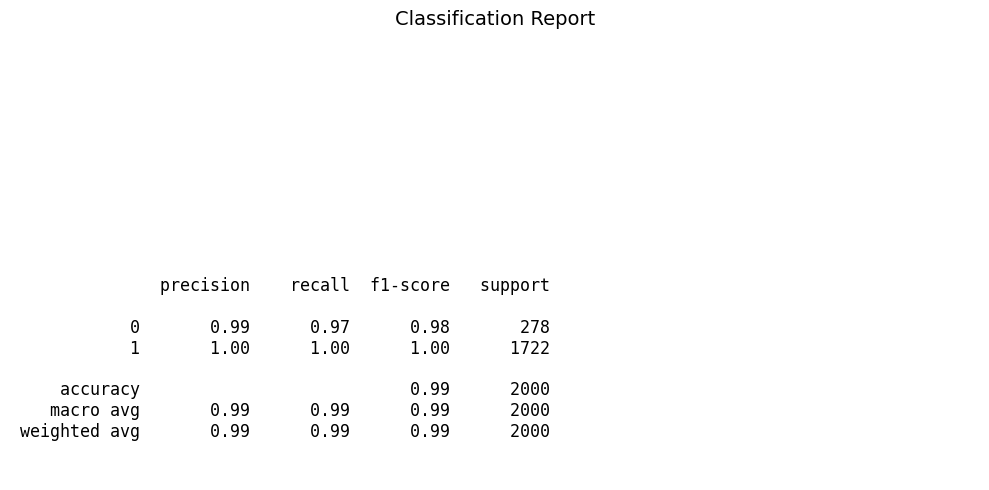

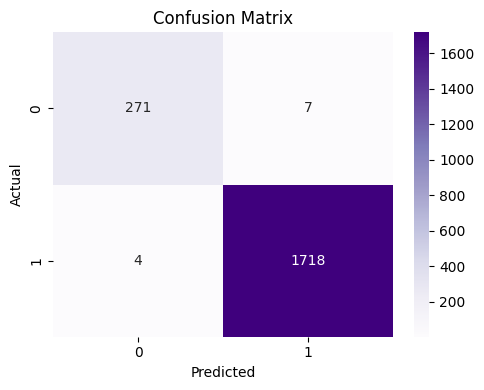

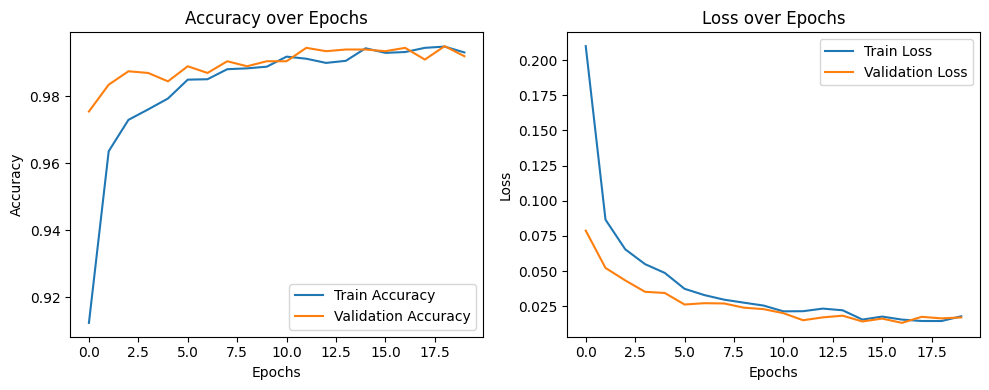

AUC Score: 0.9998


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# === Build ANN Model ===
model = Sequential([
    Dense(64, activation='relu', input_shape=(15,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# === Train Model ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# === Create Output Directory ===
os.makedirs("model_outputs", exist_ok=True)

# === Save Model ===
model.save("model_outputs/ann_model(new).keras")

# === Evaluate Model ===
y_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_prob > 0.5).astype(int)

# === Save classification report (as image with text) ===
report = classification_report(y_test, y_pred)
print(report)

plt.figure(figsize=(10, 5))
plt.axis('off')
plt.text(0.01, 0.05, report, {'fontsize': 12}, fontproperties='monospace')  # monospaced font
plt.title("Classification Report", fontsize=14)
plt.tight_layout()
plt.savefig("model_outputs/ann_classification_report.png")
plt.show()

# === Save confusion matrix heatmap ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("model_outputs/ann_confusion_matrix.png")
plt.show()

# === Plot Accuracy & Loss Curves ===
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("model_outputs/ann_training_curves.png")
plt.show()

# === AUC Score ===
auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f}")


In [1]:
# 📦 Common Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 📥 Load and prepare dataset
df = pd.read_csv('prostate_cancer_dataset.csv')
df.drop(columns=['patient_id'], inplace=True)
df['race'] = LabelEncoder().fit_transform(df['race'])  # Encode race column

# 🧪 Split data
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: scale features for MLP and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


import joblib

# ✅ Save the fitted scaler
joblib.dump(scaler, 'scaler_ann.pkl')
print("✅ Scaler saved successfully as 'scaler_ann.pkl'")


✅ Scaler saved successfully as 'scaler_ann.pkl'


🔧 Building 🧠 ANN Model...
✅ Model compiled.
🚀 Training ANN Model...
Epoch 1/50


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8398 - loss: 0.3584 - val_accuracy: 0.9610 - val_loss: 0.1148
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1266 - val_accuracy: 0.9745 - val_loss: 0.0659
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9624 - loss: 0.0873 - val_accuracy: 0.9795 - val_loss: 0.0510
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9719 - loss: 0.0728 - val_accuracy: 0.9850 - val_loss: 0.0428
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9721 - loss: 0.0640 - val_accuracy: 0.9855 - val_loss: 0.0388
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9743 - loss: 0.0602 - val_accuracy: 0.9890 - val_loss: 0.0334
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9819 - loss: 0.0443 - val_accuracy: 0.9905 - val_loss: 0.0287
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0402 - val_accuracy: 0.9915 - val_

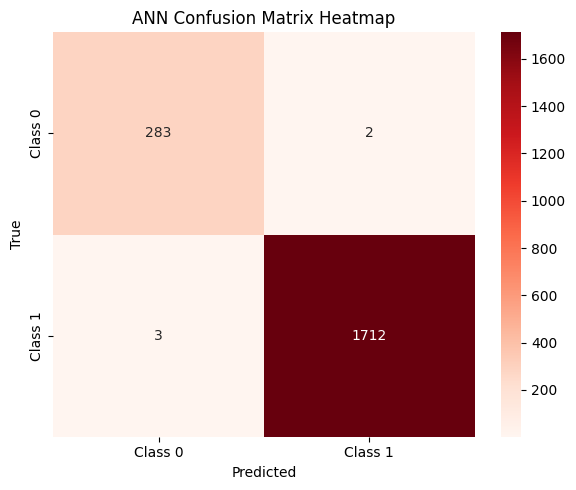

🖼️ Saved as 'model_outputs/ann_confusion_matrix_heatmap.png'.
📈 Plotting training curves...


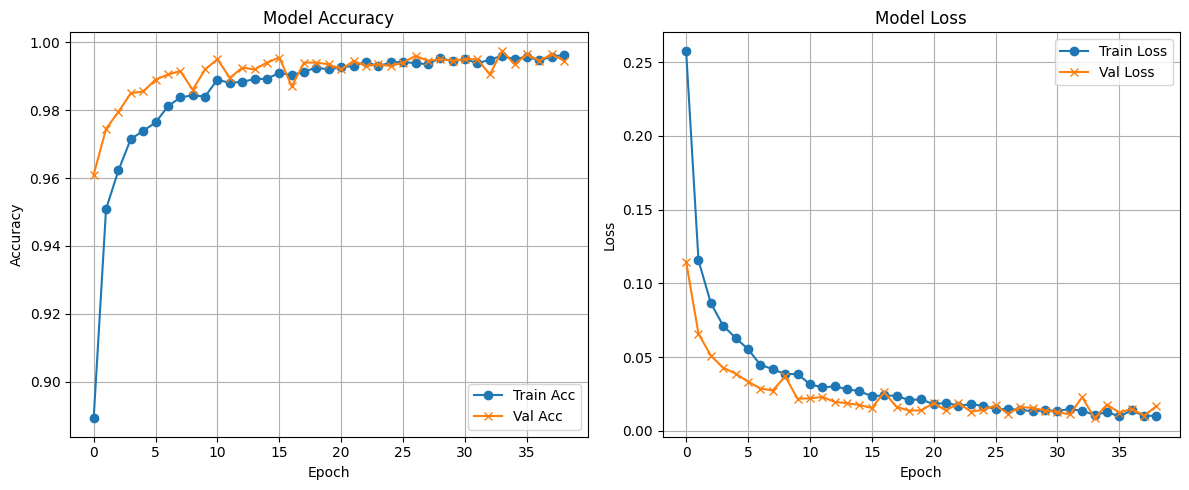

🖼️ Saved as 'model_outputs/ann_training_history.png'.
💾 Saving model to 'model_outputs/ann_model.keras'
✅ ANN Model Saved.



In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 📦 ANN model directory
os.makedirs("model_outputs", exist_ok=True)

# 🔧 Build the ANN model
print("🔧 Building 🧠 ANN Model...")
ann_model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Model compiled.")

# 🚀 Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print("🚀 Training ANN Model...")
history = ann_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
print("✅ Training complete.\n")

# 📊 Evaluate the model
print("📊 Evaluating model...")
ann_preds = (ann_model.predict(X_test_scaled) > 0.5).astype("int32")

# 🧾 Classification report
print("🧾 Classification Report:")
report = classification_report(y_test, ann_preds, target_names=['Class 0', 'Class 1'])
print(report)

# 💾 Save classification report as text
with open("model_outputs/ann_classification_report.txt", "w") as f:
    f.write(report)
print("📄 Classification report saved.")

# 📉 Confusion matrix
cm = confusion_matrix(y_test, ann_preds)
print("🔢 Confusion Matrix (raw values):\n", cm)

# 🔥 Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("ANN Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("model_outputs/ann_confusion_matrix_heatmap.png")
plt.show()
print("🖼️ Saved as 'model_outputs/ann_confusion_matrix_heatmap.png'.")

# 📈 Plot training history
print("📈 Plotting training curves...")
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='x')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("model_outputs/ann_training_history.png")
plt.show()
print("🖼️ Saved as 'model_outputs/ann_training_history.png'.")

# 💾 Save ANN model
print("💾 Saving model to 'model_outputs/ann_model.keras'")
ann_model.save("model_outputs/ann_model.keras")
print("✅ ANN Model Saved.\n")


🌲 RANDOM FOREST CLASSIFIER
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       285
           1       0.98      1.00      0.99      1715

    accuracy                           0.98      2000
   macro avg       0.99      0.95      0.97      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix (raw):
[[ 255   30]
 [   1 1714]]


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


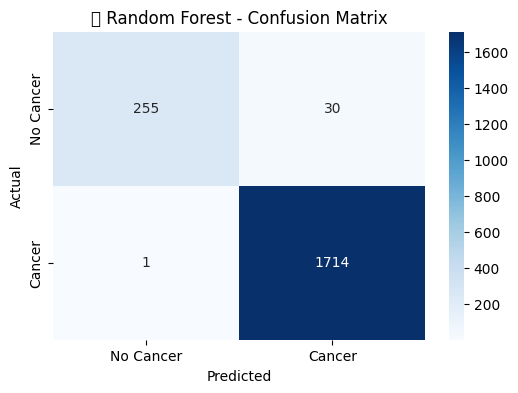

C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


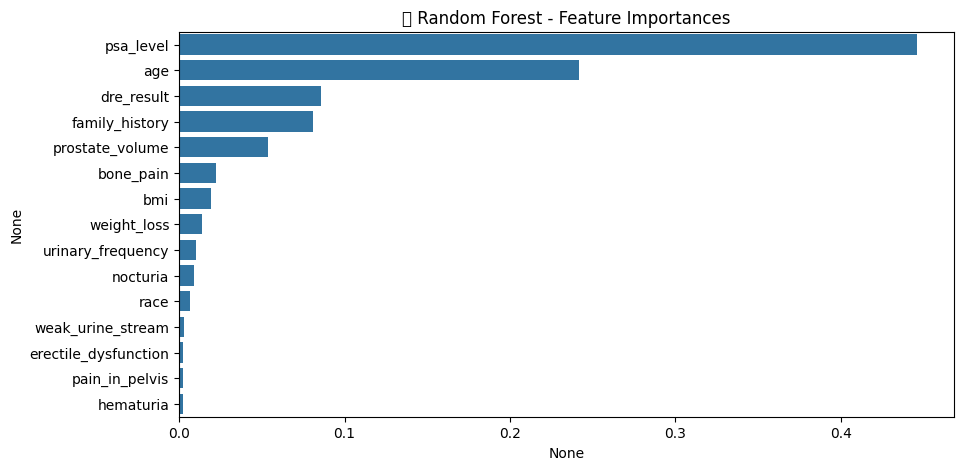

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 🌲 Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 📊 Evaluation
print("🌲 RANDOM FOREST CLASSIFIER")
print("Classification Report:")
print(classification_report(y_test, rf_preds))

# Confusion Matrix (Text)
cm_rf = confusion_matrix(y_test, rf_preds)
print("Confusion Matrix (raw):")
print(cm_rf)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
plt.title("🌲 Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("🌲 Random Forest - Feature Importances")
plt.show()


🔌 MULTILAYER PERCEPTRON (MLP)
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       285
           1       1.00      0.99      1.00      1715

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix (raw):
[[ 278    7]
 [   9 1706]]


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128268 (\N{ELECTRIC PLUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


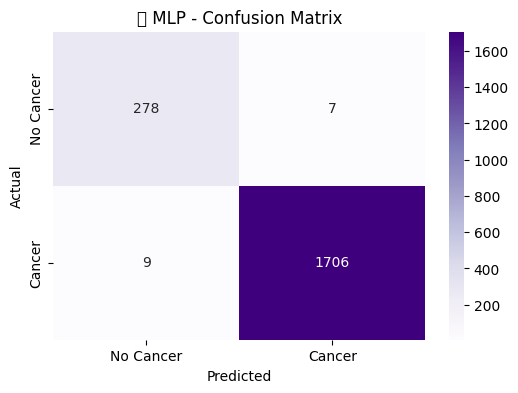

In [11]:
from sklearn.neural_network import MLPClassifier

# 🔌 MLP Classifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
mlp_preds = mlp_model.predict(X_test_scaled)

# 📊 Evaluation
print("🔌 MULTILAYER PERCEPTRON (MLP)")
print("Classification Report:")
print(classification_report(y_test, mlp_preds))

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, mlp_preds)
print("Confusion Matrix (raw):")
print(cm_mlp)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples', xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
plt.title("🔌 MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


📈 SUPPORT VECTOR MACHINE (SVM)
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       285
           1       0.98      1.00      0.99      1715

    accuracy                           0.98      2000
   macro avg       0.98      0.95      0.97      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix (raw):
[[ 257   28]
 [   5 1710]]


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


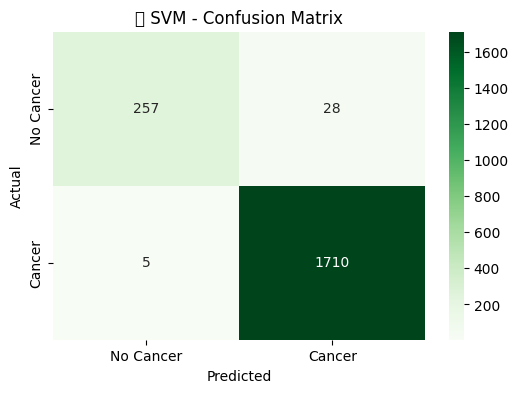

In [12]:
from sklearn.svm import SVC

# 📈 SVM Classifier
svm_model = SVC(kernel='rbf', C=1, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)

# 📊 Evaluation
print("📈 SUPPORT VECTOR MACHINE (SVM)")
print("Classification Report:")
print(classification_report(y_test, svm_preds))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
print("Confusion Matrix (raw):")
print(cm_svm)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
plt.title("📈 SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [15]:
import os
import joblib

# Ensure output folder exists
os.makedirs("model_outputs", exist_ok=True)

# Save Random Forest model
print("✅ Saving 🌲 Random Forest Model...")
joblib.dump(rf_model, "model_outputs/random_forest_model.pkl")
print("📄 Classification Report Saved for Random Forest:")
save_classification_report_image(y_test, rf_preds, "RandomForest")
print("🖼️ Confusion Matrix Saved for Random Forest:")
save_confusion_matrix_image(y_test, rf_preds, "RandomForest", cmap="Blues")
print("✅ Done with Random Forest.\n")

# Save MLP model
print("✅ Saving 🔌 MLP Model...")
joblib.dump(mlp_model, "model_outputs/mlp_model.pkl")
print("📄 Classification Report Saved for MLP:")
save_classification_report_image(y_test, mlp_preds, "MLP")
print("🖼️ Confusion Matrix Saved for MLP:")
save_confusion_matrix_image(y_test, mlp_preds, "MLP", cmap="Purples")
print("✅ Done with MLP.\n")

# Save SVM model
print("✅ Saving 📈 SVM Model...")
joblib.dump(svm_model, "model_outputs/svm_model.pkl")
print("📄 Classification Report Saved for SVM:")
save_classification_report_image(y_test, svm_preds, "SVM")
print("🖼️ Confusion Matrix Saved for SVM:")
save_confusion_matrix_image(y_test, svm_preds, "SVM", cmap="Greens")
print("✅ Done with SVM.\n")

# Save Decision Tree model
print("✅ Saving 🌳 Decision Tree Model...")
joblib.dump(model, "model_outputs/decision_tree_model.pkl")
print("📄 Classification Report Saved for Decision Tree:")
save_classification_report_image(y_test, y_pred, "DecisionTree")
print("🖼️ Confusion Matrix Saved for Decision Tree:")
save_confusion_matrix_image(y_test, y_pred, "DecisionTree", cmap="Oranges")
print("✅ Done with Decision Tree.\n")


✅ Saving 🌲 Random Forest Model...
📄 Classification Report Saved for Random Forest:
🖼️ Confusion Matrix Saved for Random Forest:
✅ Done with Random Forest.

✅ Saving 🔌 MLP Model...
📄 Classification Report Saved for MLP:
🖼️ Confusion Matrix Saved for MLP:
✅ Done with MLP.

✅ Saving 📈 SVM Model...
📄 Classification Report Saved for SVM:
🖼️ Confusion Matrix Saved for SVM:
✅ Done with SVM.

✅ Saving 🌳 Decision Tree Model...
📄 Classification Report Saved for Decision Tree:
🖼️ Confusion Matrix Saved for Decision Tree:
✅ Done with Decision Tree.

